#Modelo para predecir la probabilidad de contratación de servicios de películas de streaming

*  **Enfoque:** Predecir la probabilidad de que un cliente contrate el servicio de streaming de películas.
El modelo calculará un propensity score entre 0 y 1 para priorizar a los leads con mayor probabilidad de conversión, optimizando así las campañas y el uso del presupuesto de marketing.

*   **Datos:** Información del cliente, contrato, facturación y uso de servicios, incluyendo perfiles, tipo de contrato, precios y servicios contratados. Variables derivadas del churn no se usarán en el modelo para evitar data leakage.

*   **Métricas de negocio:** Estimación del impacto económico de la campaña optimizada:

    - Ingresos potenciales generados por los leads de alta propensión,

    - Ahorro en costes al evitar contactos innecesarios,

    - Aumento del ROI frente al enfoque tradicional de “contactar a todos”.
*   **Dataset:** https://huggingface.co/datasets/aai510-group1/telco-customer-churn

#Importación de librerías y base de datos

In [1]:
#Importación de librerías
import pandas as pd
import numpy as np
import sklearn as sk
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('bmh')

In [2]:
from datasets import load_dataset

df = load_dataset("aai510-group1/telco-customer-churn")

c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
pd.set_option('display.max_columns', None)

In [5]:
from datasets import load_dataset

# Carga el dataset
dataset = load_dataset("aai510-group1/telco-customer-churn")

# Convertimos el split 'train' a DataFrame
train_df = dataset["train"].to_pandas()

# Ahora sí puedes usar head()
train_df.head()


,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,Country,Customer ID,Customer Status,Dependents,Device Protection Plan,Gender,Internet Service,Internet Type,Lat Long,Latitude,Longitude,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Offer,Online Backup,Online Security,Paperless Billing,Partner,Payment Method,Phone Service,Population,Premium Tech Support,Quarter,Referred a Friend,Satisfaction Score,Senior Citizen,State,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code
0,72,4,19.44,0,None,None,51,San Mateo,4849,Two Year,United States,4526-ZJJTM,Stayed,0,1,Female,1,Fiber Optic,"37.538309, -122.305109",37.538309,-122.305109,1,88.40,0,0,1,None,1,0,0,1,Bank Withdrawal,1,37926,0,Q3,1,3,1,California,1,1,0,25,2191.15,0,486.00,0.0,2677.15,0,1,94403
1,27,59,45.62,0,None,None,27,Sutter Creek,3715,Month-to-Month,United States,5302-BDJNT,Stayed,0,1,Male,1,Fiber Optic,"38.432145, -120.77069",38.432145,-120.770690,0,95.50,1,0,0,None,0,0,0,0,Bank Withdrawal,1,4610,1,Q3,0,3,0,California,0,0,1,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685
2,59,0,16.07,0,None,None,59,Santa Cruz,5092,Month-to-Month,United States,5468-BPMMO,Stayed,0,0,Male,0,None,"37.007882, -122.065975",37.007882,-122.065975,1,19.60,0,0,3,None,0,0,0,1,Bank Withdrawal,1,4563,0,Q3,1,5,0,California,0,0,0,46,851.20,0,739.22,0.0,1590.42,0,0,95064
3,25,27,0.00,0,None,None,49,Brea,2068,One Year,United States,2212-LYASK,Stayed,0,1,Male,1,DSL,"33.924143, -117.79387",33.924143,-117.793870,1,45.85,0,0,3,None,1,0,1,1,Credit Card,0,1408,0,Q3,1,4,0,California,1,1,0,27,1246.40,30,0.00,0.0,1276.40,1,0,92823
4,31,21,17.22,1,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,United States,0378-XSZPU,Churned,0,1,Male,1,Cable,"37.311088, -121.961786",37.311088,-121.961786,1,60.30,0,0,1,Offer B,1,1,0,1,Credit Card,1,29914,0,Q3,1,2,0,California,0,0,0,58,3563.80,0,998.76,0.0,4562.56,0,1,95117


In [9]:
from datasets import load_dataset
import pandas as pd

# Carga el dataset completo
dataset = load_dataset("aai510-group1/telco-customer-churn")

# Convierte cada split a DataFrame
train_df = dataset["train"].to_pandas()
val_df   = dataset["validation"].to_pandas()
test_df  = dataset["test"].to_pandas()

# Agrega una columna opcional para saber el split original
train_df['split'] = 'train'
val_df['split']   = 'validation'
test_df['split']  = 'test'

# Une todos los splits en un solo DataFrame
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

#Exploración de los datos (EDA)

##Estructura de los datos

In [10]:
#Vista rápida de los datos
df.head()

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,Country,Customer ID,Customer Status,Dependents,Device Protection Plan,Gender,Internet Service,Internet Type,Lat Long,Latitude,Longitude,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Offer,Online Backup,Online Security,Paperless Billing,Partner,Payment Method,Phone Service,Population,Premium Tech Support,Quarter,Referred a Friend,Satisfaction Score,Senior Citizen,State,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,split
0,72,4,19.44,0,None,None,51,San Mateo,4849,Two Year,United States,4526-ZJJTM,Stayed,0,1,Female,1,Fiber Optic,"37.538309, -122.305109",37.538309,-122.305109,1,88.40,0,0,1,None,1,0,0,1,Bank Withdrawal,1,37926,0,Q3,1,3,1,California,1,1,0,25,2191.15,0,486.00,0.0,2677.15,0,1,94403,train
1,27,59,45.62,0,None,None,27,Sutter Creek,3715,Month-to-Month,United States,5302-BDJNT,Stayed,0,1,Male,1,Fiber Optic,"38.432145, -120.77069",38.432145,-120.770690,0,95.50,1,0,0,None,0,0,0,0,Bank Withdrawal,1,4610,1,Q3,0,3,0,California,0,0,1,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685,train
2,59,0,16.07,0,None,None,59,Santa Cruz,5092,Month-to-Month,United States,5468-BPMMO,Stayed,0,0,Male,0,None,"37.007882, -122.065975",37.007882,-122.065975,1,19.60,0,0,3,None,0,0,0,1,Bank Withdrawal,1,4563,0,Q3,1,5,0,California,0,0,0,46,851.20,0,739.22,0.0,1590.42,0,0,95064,train
3,25,27,0.00,0,None,None,49,Brea,2068,One Year,United States,2212-LYASK,Stayed,0,1,Male,1,DSL,"33.924143, -117.79387",33.924143,-117.793870,1,45.85,0,0,3,None,1,0,1,1,Credit Card,0,1408,0,Q3,1,4,0,California,1,1,0,27,1246.40,30,0.00,0.0,1276.40,1,0,92823,train
4,31,21,17.22,1,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,United States,0378-XSZPU,Churned,0,1,Male,1,Cable,"37.311088, -121.961786",37.311088,-121.961786,1,60.30,0,0,1,Offer B,1,1,0,1,Credit Card,1,29914,0,Q3,1,2,0,California,0,0,0,58,3563.80,0,998.76,0.0,4562.56,0,1,95117,train


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Avg Monthly GB Download            7043 non-null   int64  
 2   Avg Monthly Long Distance Charges  7043 non-null   float64
 3   Churn                              7043 non-null   int64  
 4   Churn Category                     1869 non-null   object 
 5   Churn Reason                       1869 non-null   object 
 6   Churn Score                        7043 non-null   int64  
 7   City                               7043 non-null   object 
 8   CLTV                               7043 non-null   int64  
 9   Contract                           7043 non-null   object 
 10  Country                            7043 non-null   object 
 11  Customer ID                        7043 non-null   objec

In [12]:
#Análisis univariado
df.describe(include='all')

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,Country,Customer ID,Customer Status,Dependents,Device Protection Plan,Gender,Internet Service,Internet Type,Lat Long,Latitude,Longitude,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Offer,Online Backup,Online Security,Paperless Billing,Partner,Payment Method,Phone Service,Population,Premium Tech Support,Quarter,Referred a Friend,Satisfaction Score,Senior Citizen,State,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,split
count,7043.000000,7043.000000,7043.000000,7043.000000,1869,1869,7043.000000,7043,7043.000000,7043,7043,7043,7043,7043.000000,7043.000000,7043,7043.000000,5517,7043,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,3166,7043.000000,7043.000000,7043.000000,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043,7043
unique,NaN,NaN,NaN,NaN,5,20,NaN,1106,NaN,3,1,7043,3,NaN,NaN,2,NaN,3,1679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1626,3
top,NaN,NaN,NaN,NaN,Competitor,Competitor had better devices,NaN,Los Angeles,NaN,Month-to-Month,United States,4526-ZJJTM,Stayed,NaN,NaN,Male,NaN,Fiber Optic,"33.362575, -117.299644",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer B,NaN,NaN,NaN,NaN,Bank Withdrawal,NaN,NaN,NaN,Q3,NaN,NaN,NaN,California,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92028,train
freq,NaN,NaN,NaN,NaN,841,313,NaN,293,NaN,3610,7043,1,4720,NaN,NaN,3555,NaN,3035,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,824,NaN,NaN,NaN,NaN,3909,NaN,NaN,NaN,7043,NaN,NaN,NaN,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43,4225
mean,46.509726,20.515405,22.958954,0.265370,NaN,NaN,58.505040,NaN,4400.295755,NaN,NaN,NaN,NaN,0.231010,0.343888,NaN,0.783331,NaN,NaN,36.197455,-119.756684,0.483033,64.761692,0.421837,0.468692,1.951867,NaN,0.344881,0.286668,0.592219,0.483033,NaN,0.903166,22139.603294,0.290217,NaN,0.457476,3.244924,0.162147,NaN,0.387903,0.353259,0.384353,32.386767,2280.381264,6.860713,749.099262,1.962182,3034.379056,0.198921,0.673719,NaN,NaN
std,16.750352,20.418940,15.448113,0.441561,NaN,NaN,21.170031,NaN,1183.057152,NaN,NaN,NaN,NaN,0.421508,0.475038,NaN,0.412004,NaN,NaN,2.468929,2.154425,0.499748,30.090047,0.493888,0.962802,3.001199,NaN,0.475363,0.452237,0.491457,0.499748,NaN,0.295752,21152.392837,0.453895,NaN,0.498224,1.201657,0.368612,NaN,0.487307,0.478016,0.486477,24.542061,2266.220462,25.104978,846.660055,7.902614,2865.204542,0.399217,0.468885,NaN,NaN
min,19.000000,0.000000,0.000000,0.000000,NaN,NaN,5.000000,NaN,2003.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,NaN,NaN,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,11.000000,0.000000,NaN,0.000000,1.000000,0.000000,NaN,0.000000,0.000000,0.000000,1.000000,18.800000,0.000000,0.000000,0.000000,21.360000,0.000000,0.000000,NaN,NaN
25%,32.000000,3.000000,9.210000,0.000000,NaN,NaN,40.000000,NaN,3469.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,33.990646,-121.788090,0.000000,35.500000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,2344.000000,0.000000,NaN,0.000000,3.000000,0.000000,NaN,0.000000,0.000000,0.000000,9.000000,400.150000,0.000000,70.545000,0.000000,605.610000,0.000000,0.000000,NaN,NaN
50%,46.000000,17.000000,22.890000,0.000000,NaN,NaN,61.000000,NaN,4527.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,36.205465,-119.595293,0.000000,70.350000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,1.000000,0.000000,NaN,1.000000,17554.000000,0.000000,NaN,0.000000,3.000

In [13]:
for col in df.columns:
    print(col, df[col].unique())

Age [72 27 59 25 31 32 36 48 54 67 79 20 30 62 71 22 38 46 47 68 60 50 80 76
 34 28 69 35 37 39 63 44 74 66 33 58 19 56 26 49 42 23 41 61 75 43 29 21
 45 77 73 64 24 78 53 55 40 51 57 52 65 70]
Avg Monthly GB Download [ 4 59  0 27 21 30  8 16 14 12 22  2 71 23  7 13  9 20  3 19 28  5 10 11
 52 56  6 76 15 26 57 85 51 24 25 18 48 53 73 17 69 29 41 47 42 82 75 58
 46 39]
Avg Monthly Long Distance Charges [19.44 45.62 16.07 ... 48.84 42.74  1.4 ]
Churn [0 1]
Churn Category [None 'Dissatisfaction' 'Competitor' 'Price' 'Attitude' 'Other']
Churn Reason [None 'Network reliability' 'Competitor had better devices'
 'Price too high' 'Competitor offered higher download speeds'
 'Competitor offered more data' 'Attitude of support person'
 'Competitor made better offer' "Don't know"
 'Attitude of service provider' 'Limited range of services'
 'Product dissatisfaction' 'Long distance charges'
 'Poor expertise of online support'
 'Lack of affordable download/upload speed' 'Service dissatisfaction'
 '

In [14]:
df.isnull().sum()

Age                                     0
Avg Monthly GB Download                 0
Avg Monthly Long Distance Charges       0
Churn                                   0
Churn Category                       5174
Churn Reason                         5174
Churn Score                             0
City                                    0
CLTV                                    0
Contract                                0
Country                                 0
Customer ID                             0
Customer Status                         0
Dependents                              0
Device Protection Plan                  0
Gender                                  0
Internet Service                        0
Internet Type                        1526
Lat Long                                0
Latitude                                0
Longitude                               0
Married                                 0
Monthly Charge                          0
Multiple Lines                    

##Análisis univariado

Para mantener una separación correcta entre tipos de variables durante el EDA, distinguimos tres grupos:
*   Numéricas (edad, cargos, consumos, etc.)
*   Categóricas verdaderas (Contract, Payment Method, Internet Type…)
*   Variables binarias codificadas a 0/1 (Partner, Gender, Paperless Billing…)

In [16]:
#Distinguimos las variables binarias
binary_vars = [
    "Dependents", "Device Protection Plan", "Internet Service",
    "Married", "Multiple Lines", "Online Backup", "Online Security",
    "Paperless Billing", "Partner", "Phone Service",
    "Premium Tech Support", "Referred a Friend", "Senior Citizen",
    "Streaming Movies", "Streaming Music", "Streaming TV",
    "Under 30", "Unlimited Data", "Churn"
]

In [17]:
#Definimos las variables numéricas y categóricas
num_cols_raw = df.select_dtypes(include=np.number).columns.tolist()
cat_cols_raw = df.select_dtypes(include="object").columns.tolist()
cat_and_binary_raw = df.select_dtypes(include="object").columns.tolist() + [col for col in binary_vars if col in df.columns]

print("Numéricas originales:", num_cols_raw)
print("Categóricas originales:", cat_cols_raw)
print("Categóricas y binarias originales:", cat_and_binary_raw)

Numéricas originales: ['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Churn', 'Churn Score', 'CLTV', 'Dependents', 'Device Protection Plan', 'Internet Service', 'Latitude', 'Longitude', 'Married', 'Monthly Charge', 'Multiple Lines', 'Number of Dependents', 'Number of Referrals', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner', 'Phone Service', 'Population', 'Premium Tech Support', 'Referred a Friend', 'Satisfaction Score', 'Senior Citizen', 'Streaming Movies', 'Streaming Music', 'Streaming TV', 'Tenure in Months', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Total Revenue', 'Under 30', 'Unlimited Data']
Categóricas originales: ['Churn Category', 'Churn Reason', 'City', 'Contract', 'Country', 'Customer ID', 'Customer Status', 'Gender', 'Internet Type', 'Lat Long', 'Offer', 'Payment Method', 'Quarter', 'State', 'Zip Code', 'split']
Categóricas y binarias originales: ['Churn Category', 'Churn Reas

In [18]:
num = [
    col for col in df.columns
    if df[col].dtype in [int, float]
    and col not in binary_vars
]

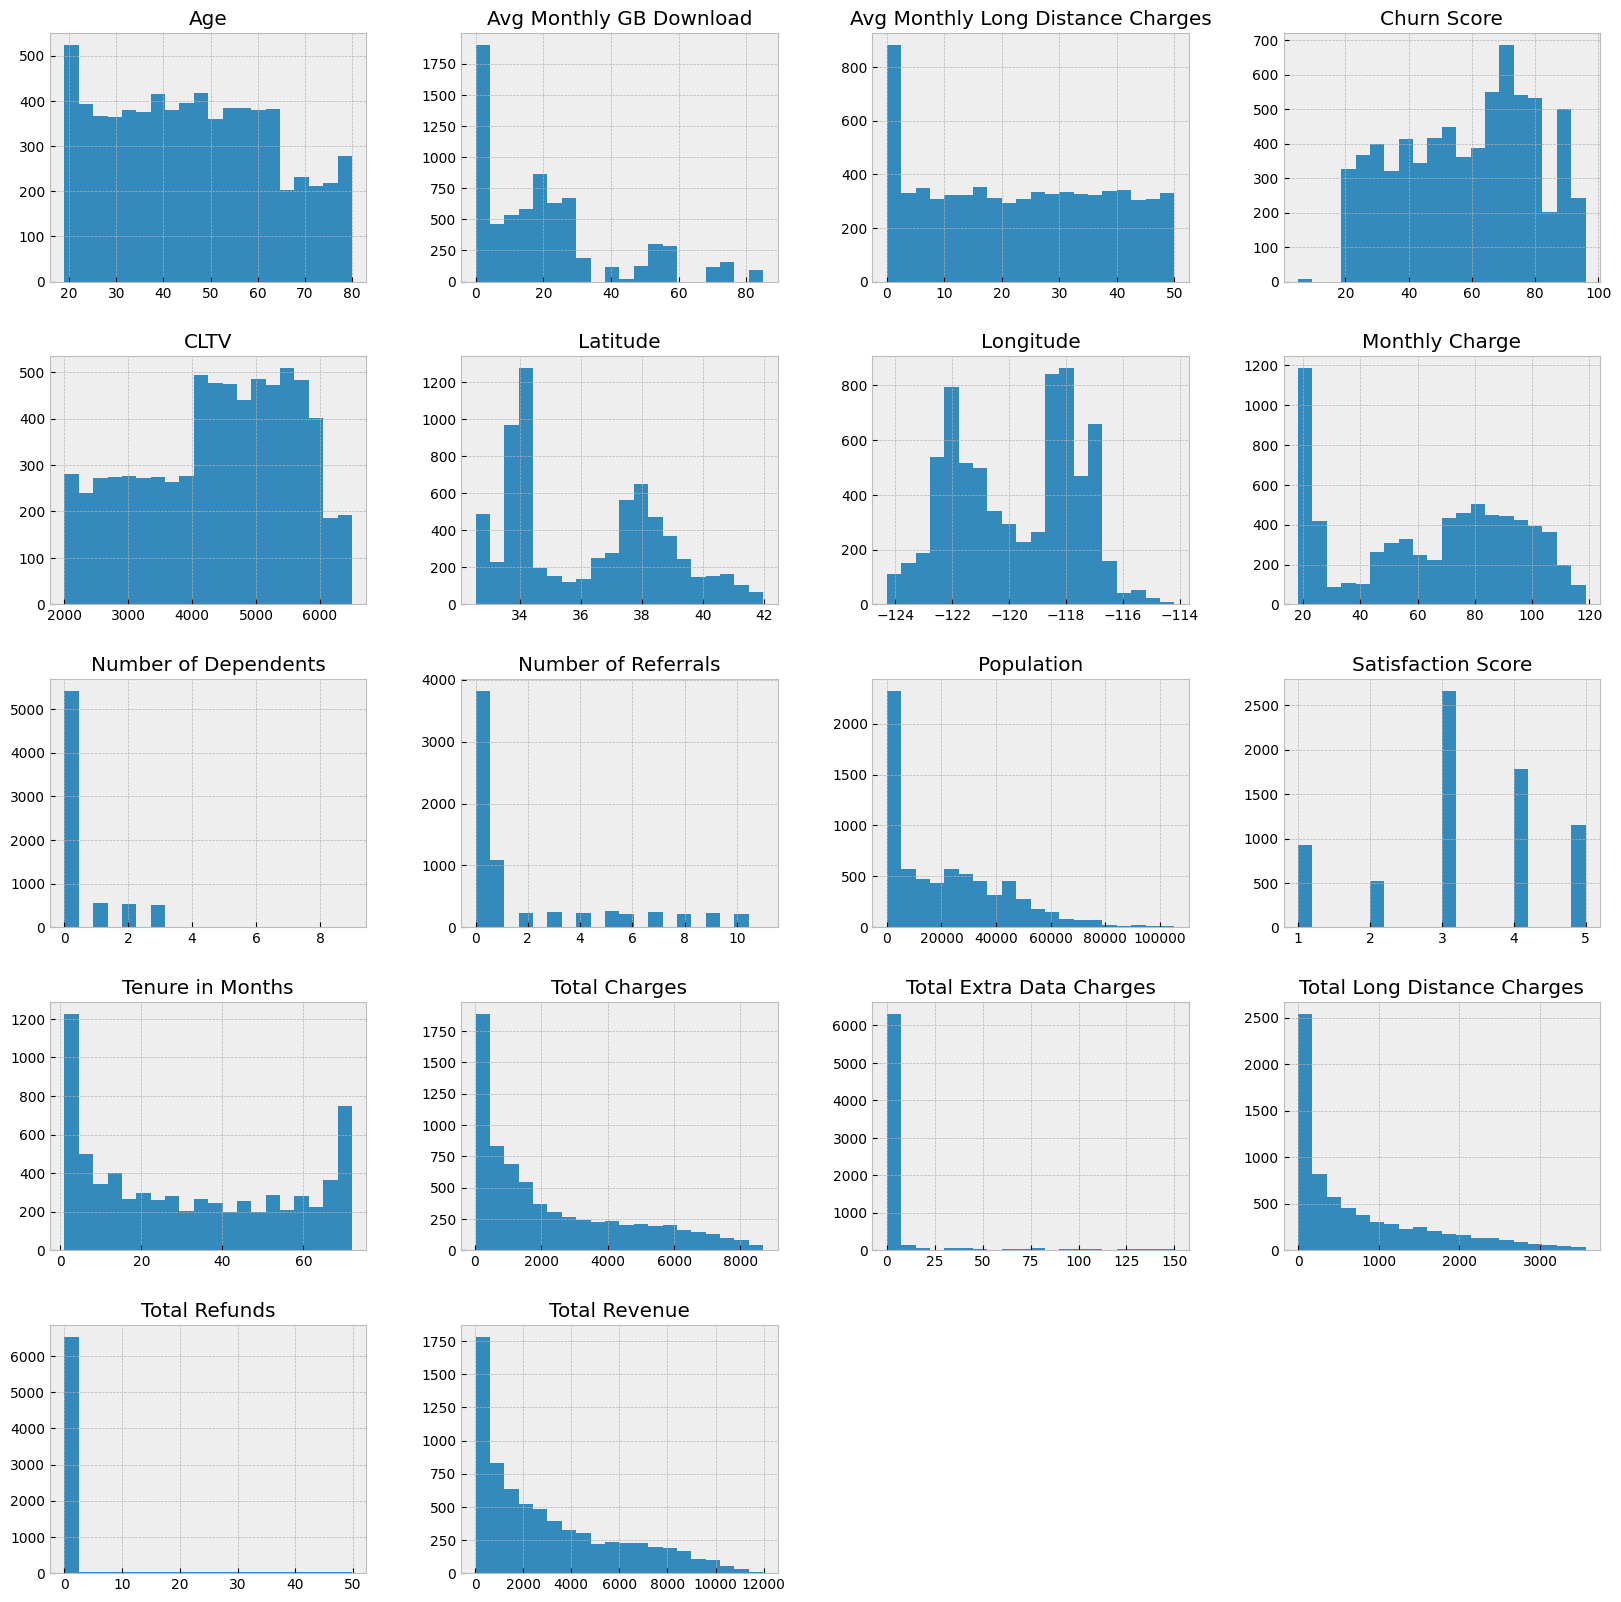

In [19]:
#Representación variables numéricas
df[num].hist(bins=20, figsize=(20,20))
plt.show()

Las variables Total Charges, Total Revenue, Total Extra Data Charges y Total Long Distance Charges tienen una distribución muy sesgada por los valores altos de algunos clientes.

Esta cola larga puede distorsionar algunos modelos, por lo que aplicaremos la transformación logarítmica (log) para reducir el efecto de los valores extremos y estabilizar la escala de la variable.

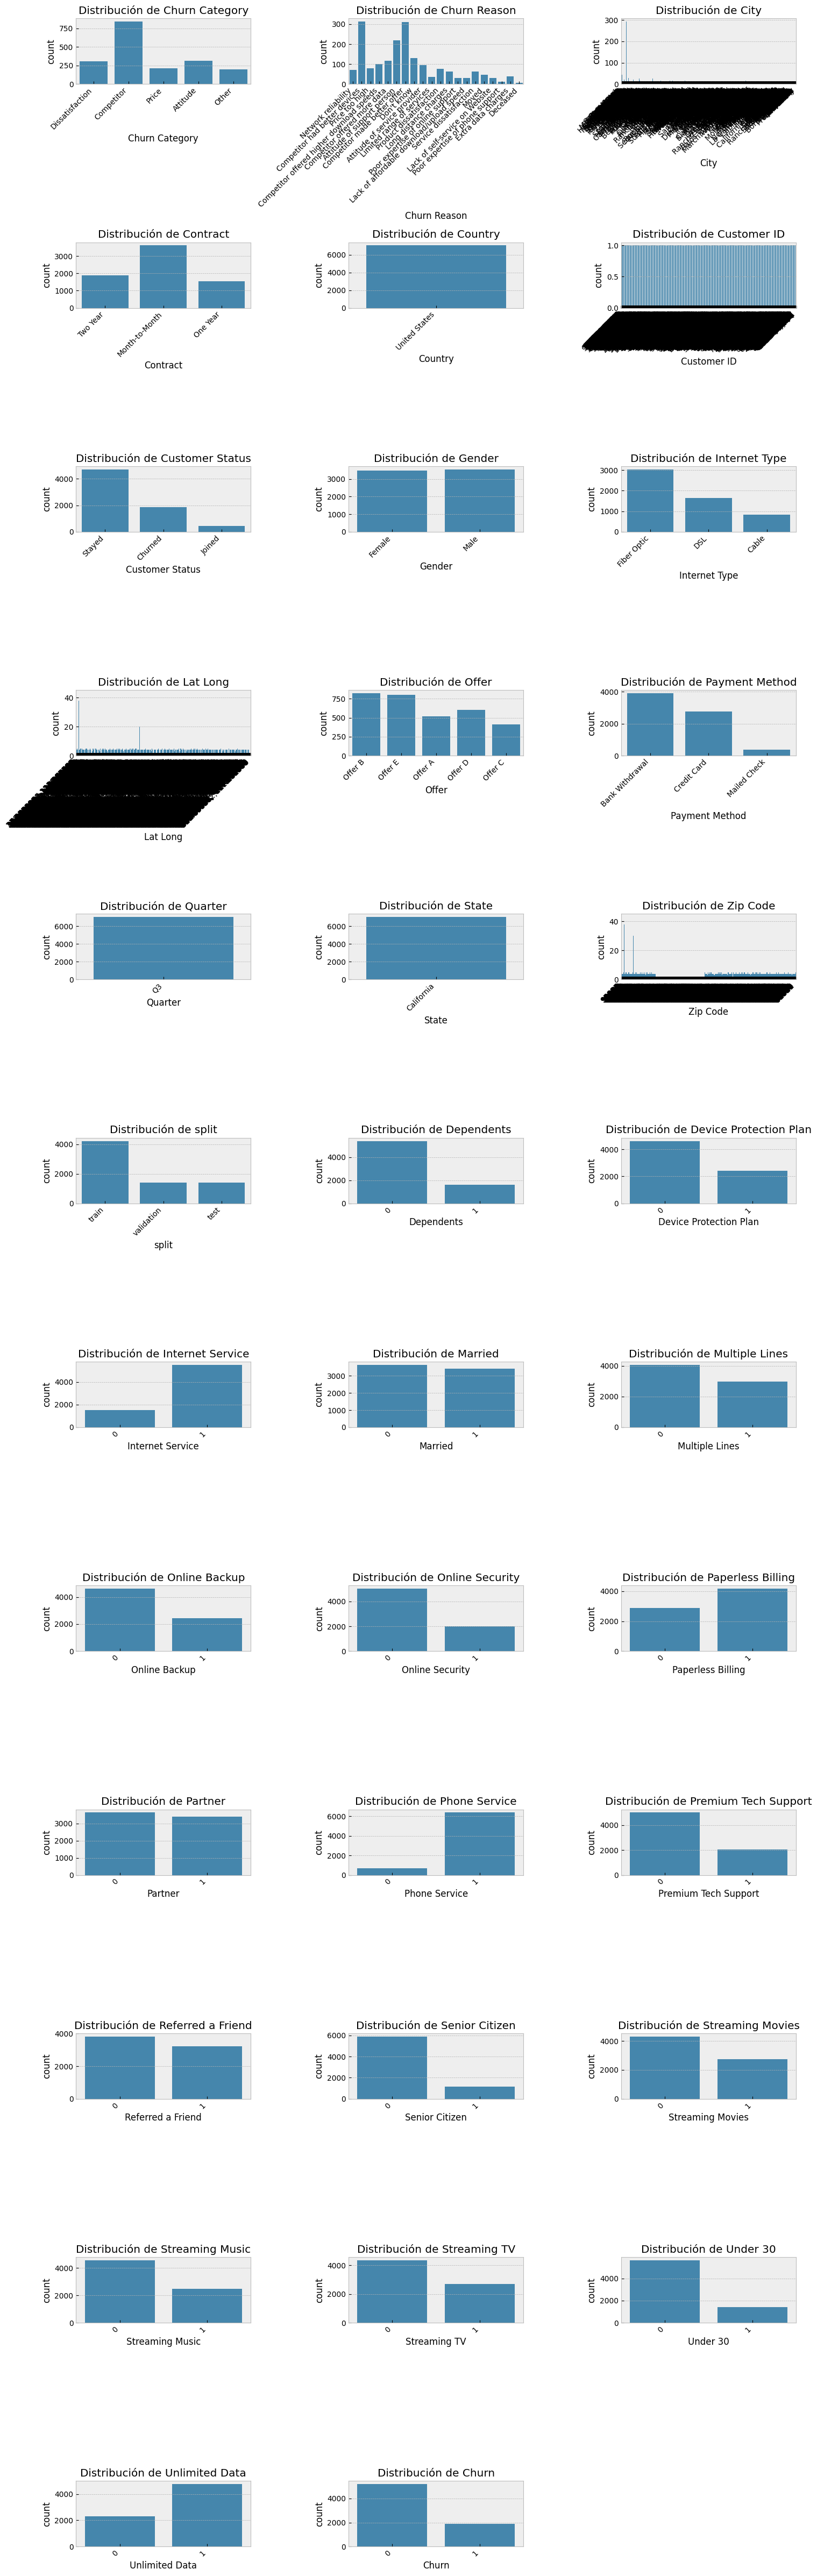

In [20]:
#Distribución variables categóricas y binarias
num_plots = len(cat_and_binary_raw )
num_cols = 3 # Número de filas en la cuadrícula
num_rows = (num_plots + num_cols - 1) // num_cols # Calcula las filas necesarias

plt.figure(figsize=(num_cols * 5, num_rows * 4)) # Para ajustar el tamaño de la figura

for i, col in enumerate(cat_and_binary_raw ):
    plt.subplot(num_rows, num_cols, i + 1) # Crea subplots
    sns.countplot(x=df[col])
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45, ha='right') # Rota las etiquetas para mejorar la legibilidad

plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se superpongan
plt.show()

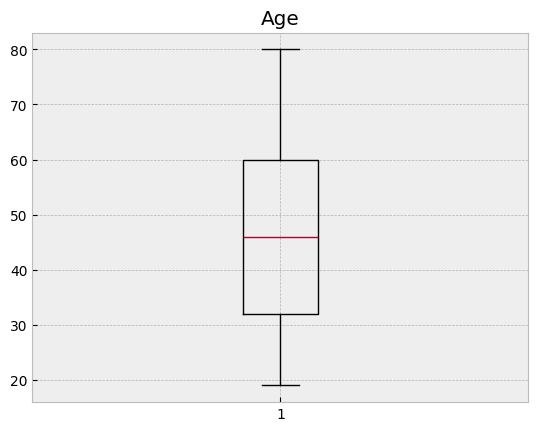

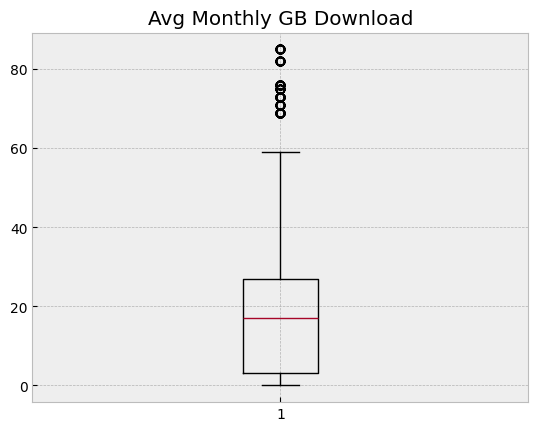

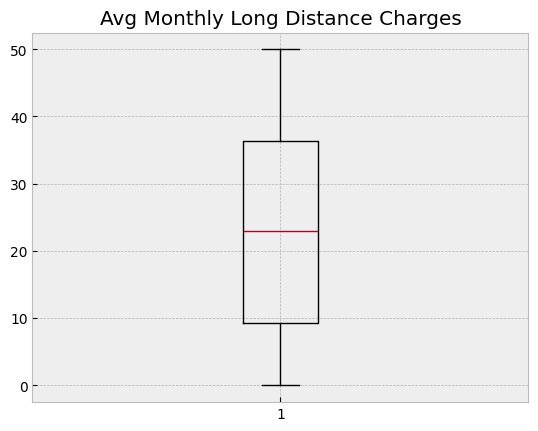

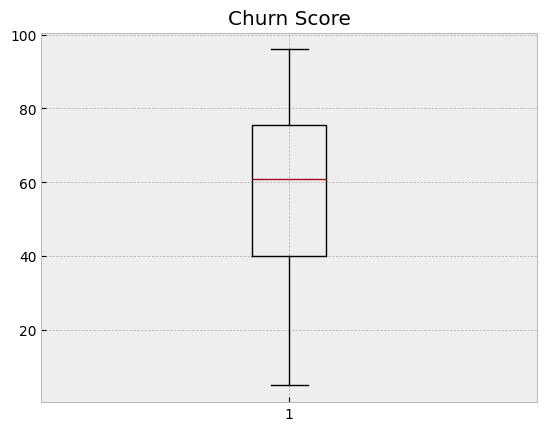

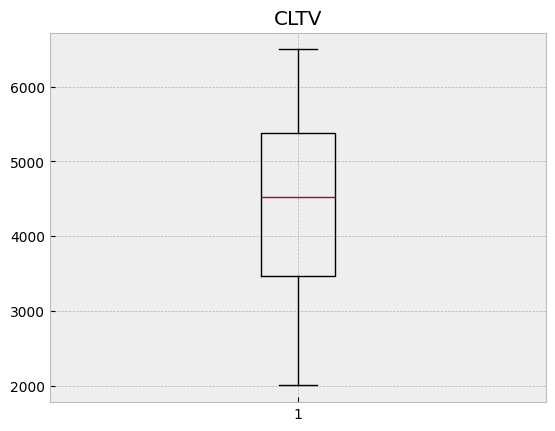

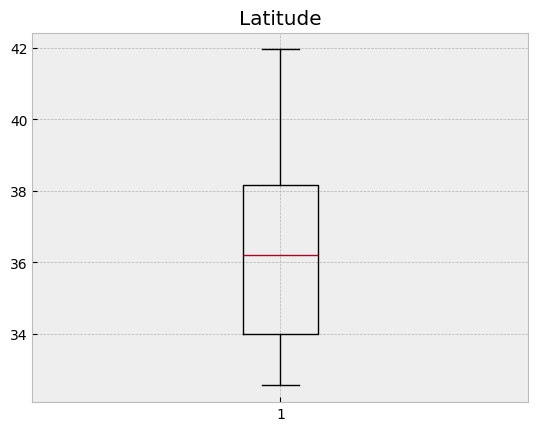

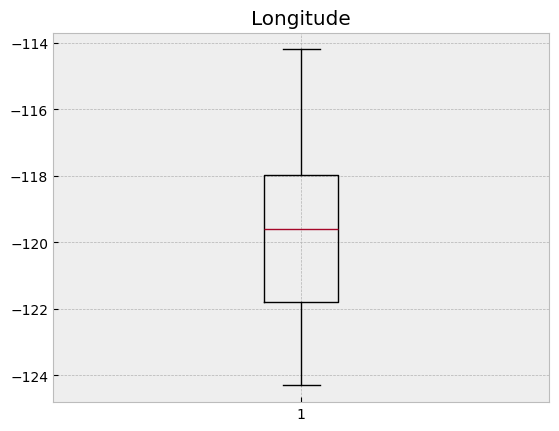

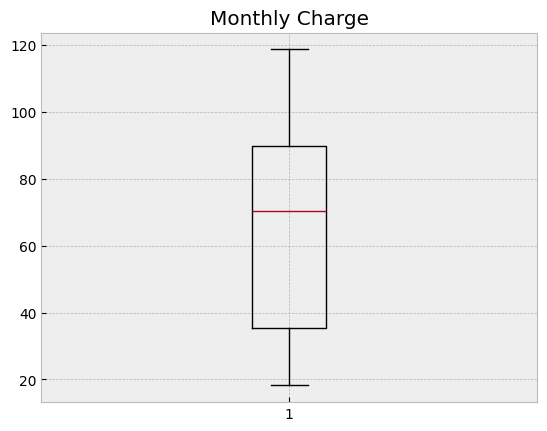

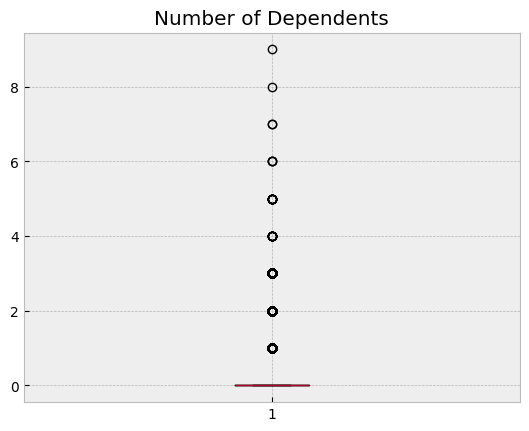

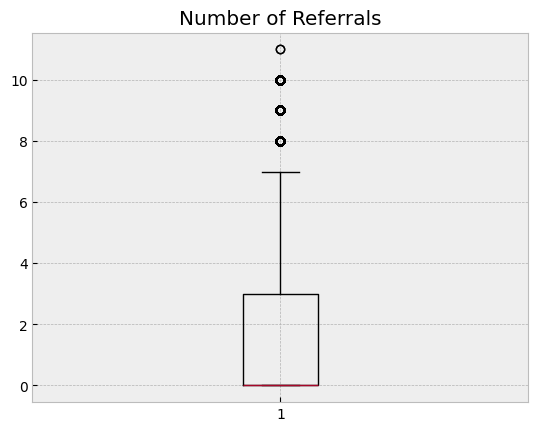

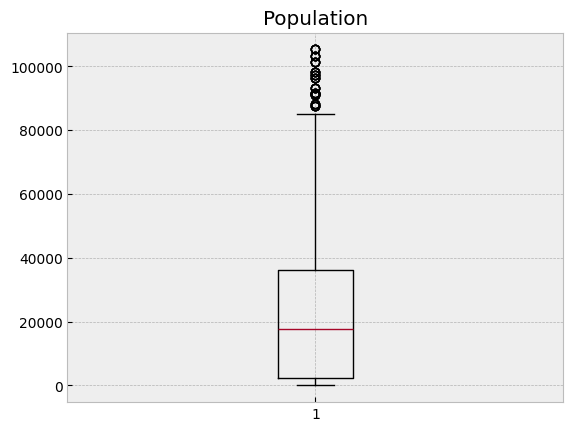

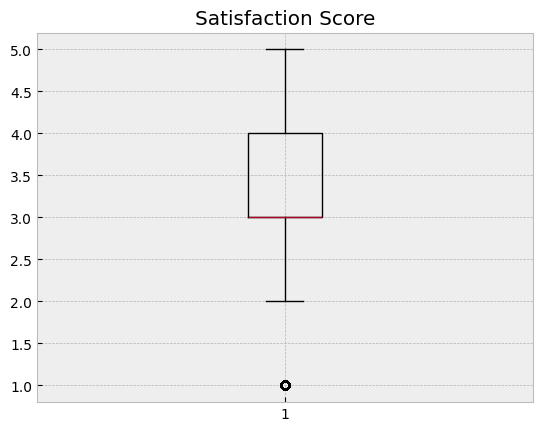

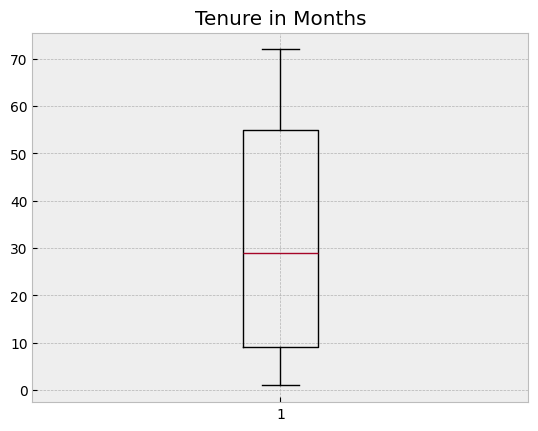

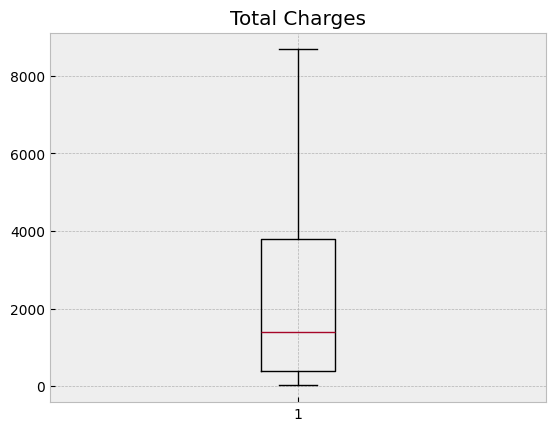

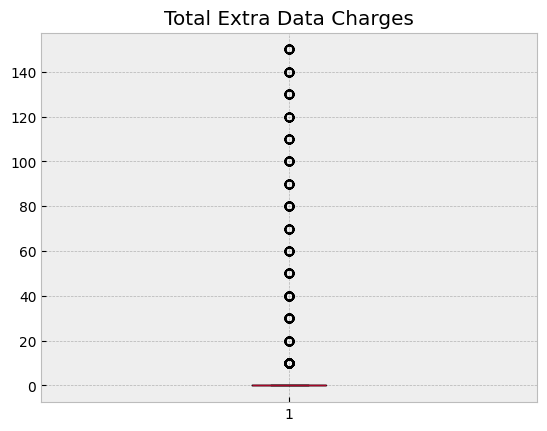

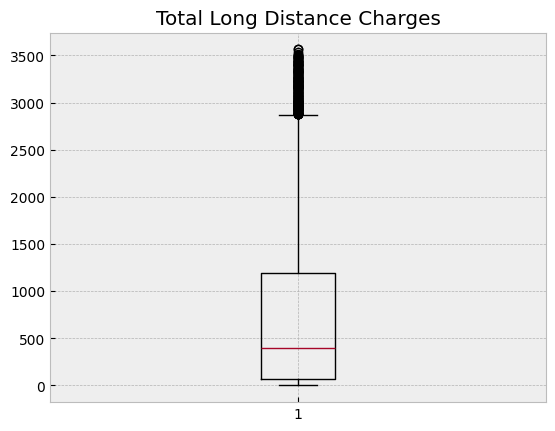

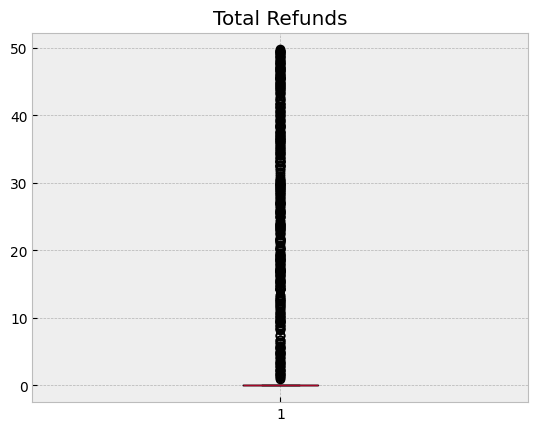

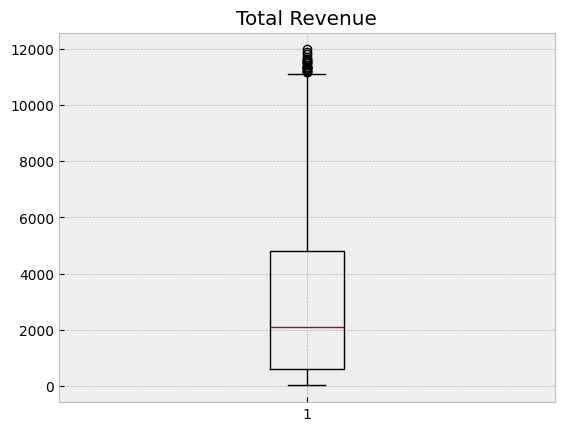

In [21]:
#Boxplot por variable
for col in num:
    fig, ax = plt.subplots()
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    plt.show()

In [22]:
def detectar_outliers_iqr(df, columnas):
    outlier_info = {}

    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        outlier_info[col] = len(outliers)

    return outlier_info

outliers_detectados = detectar_outliers_iqr(df, num)
outliers_detectados


{'Age': 0,
 'Avg Monthly GB Download': 362,
 'Avg Monthly Long Distance Charges': 0,
 'Churn Score': 0,
 'CLTV': 0,
 'Latitude': 0,
 'Longitude': 0,
 'Monthly Charge': 0,
 'Number of Dependents': 1627,
 'Number of Referrals': 676,
 'Population': 57,
 'Satisfaction Score': 922,
 'Tenure in Months': 0,
 'Total Charges': 0,
 'Total Extra Data Charges': 728,
 'Total Long Distance Charges': 196,
 'Total Refunds': 525,
 'Total Revenue': 21}

Al revisar las variables numéricas mediante boxplots y análisis de percentiles, se observan valores altos que podrían considerarse outliers según criterios estadísticos (IQR). Sin embargo, estos valores son consistentes con la naturaleza del negocio: corresponden a clientes con altos consumos o facturación acumulada, por lo que se consideran esperables y no se eliminan.

##Análisis multivariado

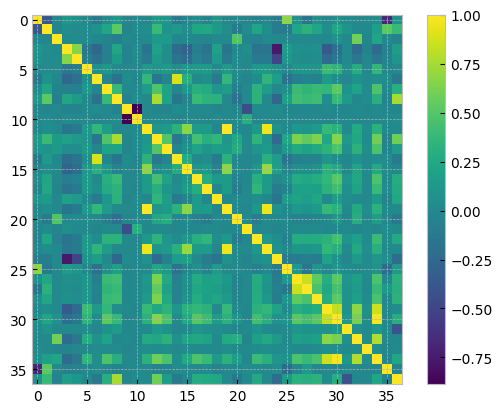

In [24]:
#Análisis multivariado - Matriz de correlación
plt.imshow(df.select_dtypes(include=np.number).corr())
plt.colorbar()
plt.show()

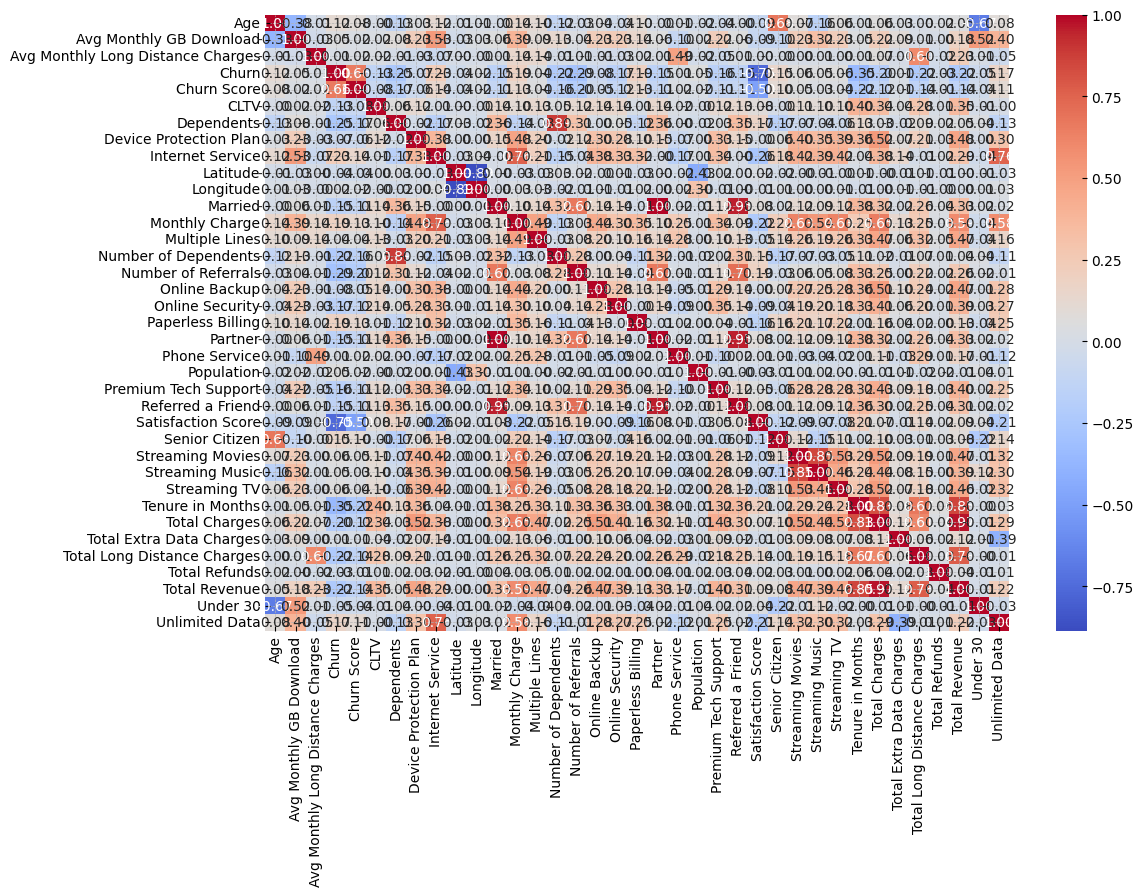

In [25]:
# Matriz de correlación numérica
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

#Preprocessing

##Limpieza de los datos

Eliminamos las siguientes variables de nuestros datos:

| Variable                            | Motivo                                                                                                                               |
| ----------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| **Customer ID**                     | Identificador único. No tiene relación con la variable objetivo y no aporta poder predictivo.                                        |
| **Country**                         | Toda la muestra es de EEUU. No aporta variabilidad ni información útil.                                                              |
| **State**                           | Toda la muestra es de California. No aporta variabilidad ni información útil.                                                        |
| **City**                            | Todas las ciudades están en el mismo estado.                                                                                         |
| **Latitude / Longitude / Lat Long** | Si todos los clientes están en el mismo país o región, no aporta. Solo sería útil si hay variación geográfica significativa.         |
| **Quarter**                         | Puede ser redundante si ya tenemos `Tenure` o fecha de contratación. Además, si no se hace análisis estacional, no aporta al modelo. |
| **Churn Category**                  | Muchos NaN y tipo string. Redundante con `Churn`. Eliminación para evitar data leakage.                                              |
| **Churn Reason**                    | Muchos NaN y tipo string. Redundante con `Churn Category` y `Churn`. Se elimina.                                                     |
| **Churn Score**                     | Variable derivada de churn. Riesgo de data leakage. Se elimina porque ya se cuenta con `Churn`.                                      |
| **Zip Code**                        | Alta cardinalidad, parecido a un ID. No aporta valor predictivo y complica el modelo.                                                |
| **Population**                      | Poca variabilidad geográfica en este dataset; no aporta señal relevante.                                                             |
| **Offer**                           | Información pasada de marketing; puede generar data leakage y no refleja propensión futura al servicio de streaming.                 |
| **Under 30**                        | Redundante con `Age` y `Senior Citizen`. Se elimina para simplificar el modelo.                                                      |
| **Senior Citizen**                  | Redundante con `Age`. Se elimina para simplificar el modelo.                                                                         |


In [26]:
# Lista de columnas a eliminar
cols_to_drop = [
    'Customer ID',       # identificador único
    'Country',           # toda la muestra es EEUU
    'State',             # toda la muestra es California
    'City',              # redundante, todas están en California
    'Lat Long',          # latitud+longitud redundante
    'Latitude',          # redundante
    'Longitude',         # redundante
    'Quarter',           # poca relevancia predictiva
    'Churn Category',    # muchos NaN y redundante con Churn
    'Churn Reason',      # muchos NaN y redundante
    'Churn Score',       # derivada de Churn, riesgo de data leakage
    'Zip Code',          # alta cardinalidad, parecido a un ID
    'Population',        # poca variabilidad geográfica
    'Offer',             # riesgo de data leakage
    'Under 30',          # redundante con Age
    'Senior Citizen'     # redundante con Age
]

# Filtrar solo columnas existentes para evitar errores
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

# Eliminar columnas
df = df.drop(columns=cols_to_drop)

# Revisar el resultado
print("Columnas eliminadas:", cols_to_drop)
print("Columnas restantes:", df.columns.tolist())


Columnas eliminadas: ['Customer ID', 'Country', 'State', 'City', 'Lat Long', 'Latitude', 'Longitude', 'Quarter', 'Churn Category', 'Churn Reason', 'Churn Score', 'Zip Code', 'Population', 'Offer', 'Under 30', 'Senior Citizen']
Columnas restantes: ['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Churn', 'CLTV', 'Contract', 'Customer Status', 'Dependents', 'Device Protection Plan', 'Gender', 'Internet Service', 'Internet Type', 'Married', 'Monthly Charge', 'Multiple Lines', 'Number of Dependents', 'Number of Referrals', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner', 'Payment Method', 'Phone Service', 'Premium Tech Support', 'Referred a Friend', 'Satisfaction Score', 'Streaming Movies', 'Streaming Music', 'Streaming TV', 'Tenure in Months', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Total Revenue', 'Unlimited Data', 'split']


##Escalado de variables

Algunas variables del dataset presentan distribuciones fuertemente sesgadas hacia valores muy altos o muy bajos, típicas de cargos o consumos acumulados, con presencia de outliers que pueden distorsionar el aprendizaje del modelo.

La transformación logarítmica (log) se aplica para reducir la influencia de valores extremos, mejorar la linealidad de la relación con la variable objetivo y estabilizar la escala de la variable, facilitando que los algoritmos capturen patrones de manera más robusta y evitando que clientes con valores extraordinarios dominen el modelo.

| Variable                    | Motivo de transformación / eliminación                                                                                                              |
| --------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| Total Extra Data Charges    | Distribución fuertemente sesgada hacia valores altos debido a consumos extremos de datos. Se aplica log para reducir outliers y estabilizar escala. |
| Total Revenue               | Rango muy amplio asociado a facturación acumulada. Log reduce la influencia de clientes con ingresos extraordinarios.                               |
| Total Charges               | Distribución con cola larga que puede distorsionar modelos lineales. El log ayuda a normalizar su comportamiento.                                   |
| Total Long Distance Charges | Algunos clientes presentan importes atípicamente elevados en llamadas de larga distancia; log reduce su impacto.                                                                        

In [27]:
#Transformación logarítmica
df['Total Extra Data Charges'] = np.log(df['Total Extra Data Charges'] + 1)
df['Total Charges'] = np.log(df['Total Charges'] + 1)
df['Total Revenue'] = np.log(df['Total Revenue'] + 1)
df['Total Long Distance Charges'] = np.log(df['Total Long Distance Charges'] + 1)

##Comprobación de nulos

In [28]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]

missing_percent = (missing_data / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage (%)': missing_percent
})

missing_table = missing_table.sort_values(by='Missing Percentage (%)', ascending=False)

print(missing_table)

               Missing Count  Missing Percentage (%)
Internet Type           1526               21.666903


In [29]:
internet_type_nan_and_service = df[df['Internet Type'].isnull()]['Internet Service'].sum()

if internet_type_nan_and_service == 0:
    print("Confirmado: Los valores NaN en 'Internet Type' corresponden a clientes que no tienen contratado 'Internet Service'.")
else:
    print(f"Hay {internet_type_nan_and_service} clientes con NaN en 'Internet Type' que sí tienen 'Internet Service' contratado.")

Confirmado: Los valores NaN en 'Internet Type' corresponden a clientes que no tienen contratado 'Internet Service'.


##Codificación variables categóricas

In [30]:
# 1. Regenerar variables categóricas (object)
cat_vars = df.select_dtypes(include="object").columns.tolist()

# 2. Regenerar variables binarias (0/1 reales)
binary_vars = [
    col for col in df.columns
    if df[col].dtype in ['int64', 'int32'] and df[col].nunique() == 2
]

# 3. Seleccionar solo multiclase (categorías con >2 niveles)
cat_multiclass = [
    col for col in cat_vars
    if col not in binary_vars
]

print("Categóricas multiclase:", cat_multiclass)
print("Binarias:", binary_vars)
print("Categóricas:", cat_vars)

Categóricas multiclase: ['Contract', 'Customer Status', 'Gender', 'Internet Type', 'Payment Method', 'split']
Binarias: ['Churn', 'Dependents', 'Device Protection Plan', 'Internet Service', 'Married', 'Multiple Lines', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner', 'Phone Service', 'Premium Tech Support', 'Referred a Friend', 'Streaming Movies', 'Streaming Music', 'Streaming TV', 'Unlimited Data']
Categóricas: ['Contract', 'Customer Status', 'Gender', 'Internet Type', 'Payment Method', 'split']


In [31]:
#Codificación de variables categóricas multiclase con One-Hot Encoding
cat_multiclass = [
    col for col in df.select_dtypes(include="object").columns
    if col not in binary_vars
]

df = pd.get_dummies(df, columns=cat_multiclass, drop_first=True)
df = df.astype({col: int for col in df.columns if df[col].dtype == "bool"})  # Convertir booleanos a enteros

In [32]:
df

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,CLTV,Dependents,Device Protection Plan,Internet Service,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Online Backup,Online Security,Paperless Billing,Partner,Phone Service,Premium Tech Support,Referred a Friend,Satisfaction Score,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Unlimited Data,Contract_One Year,Contract_Two Year,Customer Status_Joined,Customer Status_Stayed,Gender_Male,Internet Type_DSL,Internet Type_Fiber Optic,Payment Method_Credit Card,Payment Method_Mailed Check,split_train,split_validation
0,72,4,19.44,0,4849,0,1,1,1,88.40,0,0,1,1,0,0,1,1,0,1,3,1,1,0,25,7.692638,0.000000,6.188264,0.0,7.892882,1,0,1,0,1,0,0,1,0,0,1,0
1,27,59,45.62,0,3715,0,1,1,0,95.50,1,0,0,0,0,0,0,1,1,0,3,0,0,1,35,8.137162,0.000000,7.376320,0.0,8.520368,1,0,0,0,1,1,0,1,0,0,1,0
2,59,0,16.07,0,5092,0,0,0,1,19.60,0,0,3,0,0,0,1,1,0,1,5,0,0,0,46,6.747821,0.000000,6.606947,0.0,7.372382,0,0,0,0,1,1,0,0,0,0,1,0
3,25,27,0.00,0,2068,0,1,1,1,45.85,0,0,3,1,0,1,1,0,0,1,4,1,1,0,27,7.128817,3.433987,0.000000,0.0,7.152582,0,1,0,0,1,1,1,0,1,0,1,0
4,31,21,17.22,1,4026,0,1,1,1,60.30,0,0,1,1,1,0,1,1,0,1,2,0,0,0,58,8.178863,0.000000,6.907515,0.0,8.425858,1,1,0,0,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,33,12,10.67,0,4847,0,1,1,0,100.55,1,0,0,0,0,0,0,1,0,0,4,1,1,1,29,7.965459,0.000000,5.737958,0.0,8.067519,1,0,0,0,1,0,0,1,0,0,0,0
7039,36,30,30.44,0,5470,0,1,1,0,95.80,0,0,0,0,0,0,0,1,0,0,3,1,1,1,59,8.640552,0.000000,7.493852,0.0,8.916293,1,0,1,0,1,0,0,1,0,0,0,0
7040,57,24,4.51,0,4471,0,1,1,0,86.45,1,0,0,0,1,0,0,1,1,0,4,1,1,1,61,8.551846,0.000000,5.620799,0.0,8.603630,1,0,1,0,1,0,0,0,1,0,0,0
7041,35,24,47.06,0,5445,0,1,1,0,55.65,0,0,0,0,1,1,0,1,0,0,3,0,0,0,30,7.411466,0.000000,7.253329,0.0,8.028341,1,0,1,0,1,1,0,0,0,1,0,0


#Selección de los datos

Eliminamos las variables que tienen un coeficiente de correlación mayor al 90%, para evitar tener multicolinealidad en nuestro modelo y obtener mejores predicciones.

In [33]:
#Eliminación de variables altamente correlacionadas
corr = df.corr()

to_drop = []
for col in corr.columns:
    for col2 in corr.columns:
        if col != col2 and abs(corr.loc[col, col2]) > 0.90:
            to_drop.append(col2)

to_drop = list(set(to_drop))
df = df.drop(columns=to_drop)
print("Variables eliminadas por correlación:", to_drop)

Variables eliminadas por correlación: ['Total Charges', 'Total Revenue', 'Referred a Friend', 'Partner', 'Married']


In [34]:
#Observación variable target
print("Clientes sin el servicio de Streaming de películas:", len(df[df['Streaming Movies']==0]))
print("Clientes con el servicio de Streaming de películas:", len(df[df['Streaming Movies']==1]))

Clientes sin el servicio de Streaming de películas: 4311
Clientes con el servicio de Streaming de películas: 2732
